In [ ]:
import pandas as pd

df = pd.read_csv("genz_social_media_usage_1M.csv")

df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179344 entries, 0 to 179343
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       179344 non-null  int64  
 1   gender                    179344 non-null  object 
 2   country                   179344 non-null  object 
 3   daily_usage_hours         179344 non-null  float64
 4   primary_platform          179344 non-null  object 
 5   num_platforms_used        179344 non-null  int64  
 6   purpose                   179344 non-null  object 
 7   avg_session_minutes       179344 non-null  float64
 8   night_usage               179344 non-null  int64  
 9   mental_health_score       179344 non-null  float64
 10  addiction_level           179344 non-null  object 
 11  screen_time_before_sleep  179344 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 16.4+ MB


In [ ]:
df.describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,179344.000000,179344.000000,179344.000000,179344.000000,179344.000000,179344.000000,179344.000000
mean,20.014057,3.513310,2.993281,25.111687,0.599418,7.170931,40.107052
std,4.317595,1.468594,1.415453,9.773105,0.490018,1.502882,19.576301
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.492595,2.000000,18.306850,0.000000,6.148068,26.422409
50%,20.000000,3.501878,3.000000,25.039033,1.000000,7.200584,39.925180
75%,24.000000,4.511668,4.000000,31.740898,1.000000,8.241602,53.407586
max,27.000000,10.000000,5.000000,69.490040,1.000000,10.000000,133.140406


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
age,0
gender,0
country,0
daily_usage_hours,0
primary_platform,0
num_platforms_used,0
purpose,0
avg_session_minutes,0
night_usage,0
mental_health_score,0


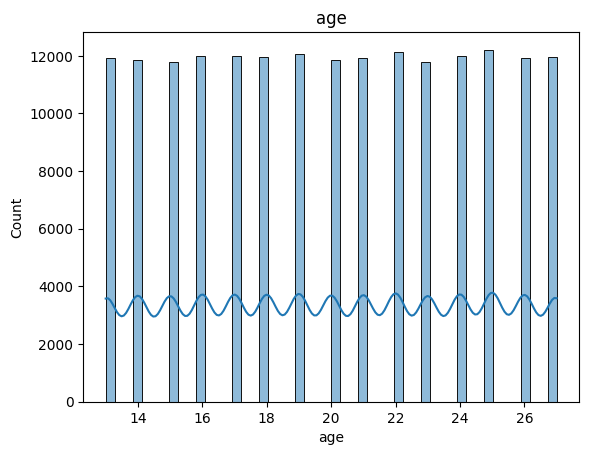

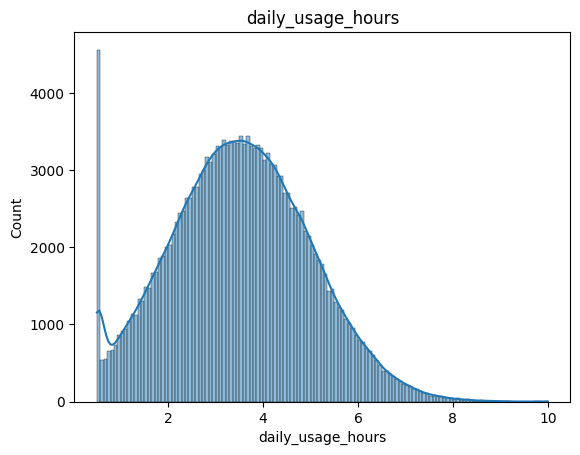

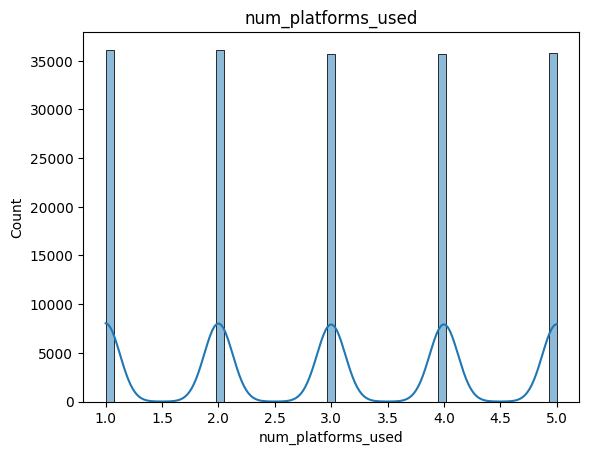

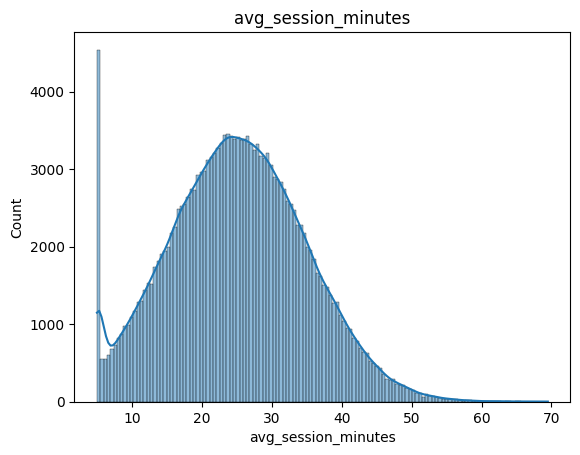

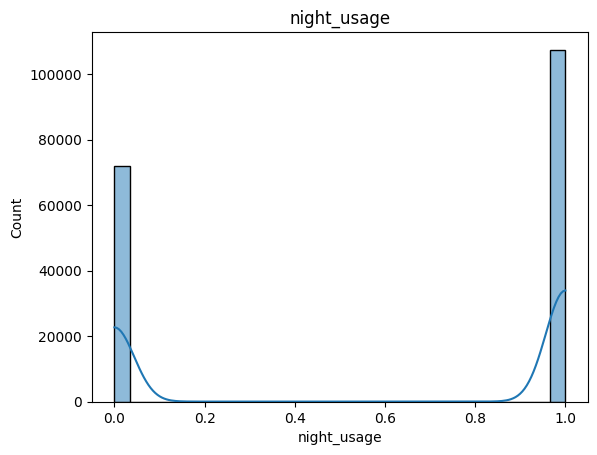

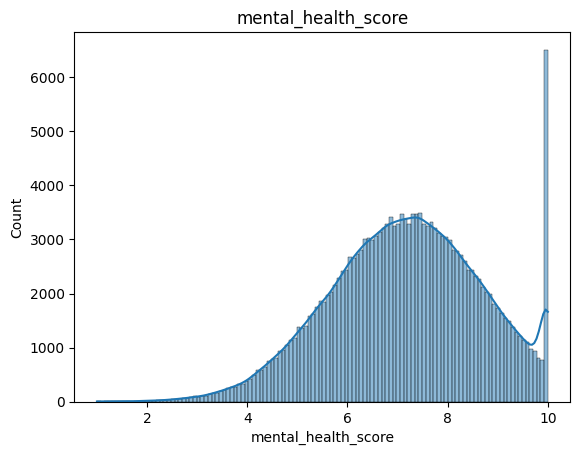

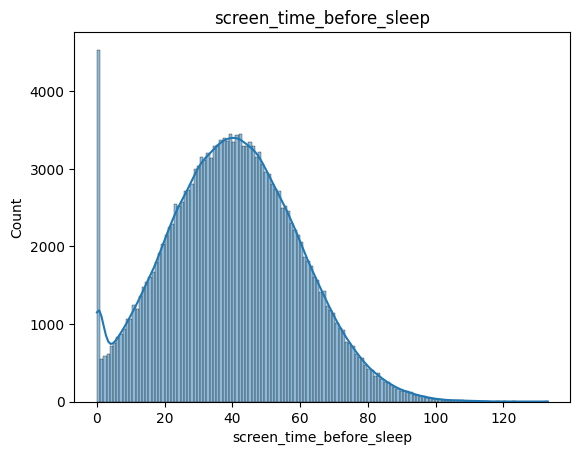

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
corr_1 = df['screen_time_before_sleep'].corr(df['mental_health_score'])
print("Correlation:", corr_1)

Correlation: -0.0027424864894056273


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(df[col].value_counts())

gender
Female    86129
Male      85994
Other      7221
Name: count, dtype: int64
country
India        63078
USA          35627
UK           18190
Canada       17906
Brazil       17850
Germany      17845
Australia     8848
Name: count, dtype: int64
primary_platform
Instagram    53921
YouTube      44850
TikTok       44695
Snapchat     17946
Twitter      17932
Name: count, dtype: int64
purpose
Entertainment       71417
Socializing         45318
Education           35913
News                17798
Content Creation     8898
Name: count, dtype: int64
addiction_level
Medium    105943
Low        45116
High       28285
Name: count, dtype: int64


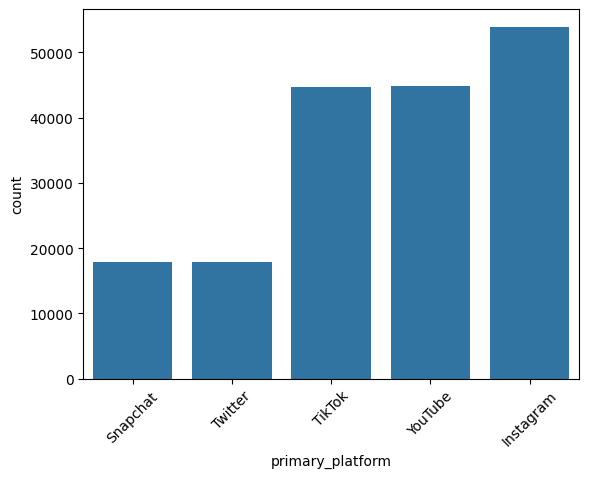

In [ ]:
sns.countplot(x='primary_platform', data=df)
plt.xticks(rotation=45)
plt.show()

# Label Encoding

In [ ]:
# Pisahkan target dulu
y = df['addiction_level']
X = df.drop('addiction_level', axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y = le_target.fit_transform(y)

print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [ ]:
X = pd.get_dummies(X, columns=['gender', 'country', 'primary_platform', 'purpose'], drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split dulu (hindari data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9989405893668627
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5668
           1       1.00      1.00      1.00      9137
           2       1.00      1.00      1.00     21064

    accuracy                           1.00     35869
   macro avg       1.00      1.00      1.00     35869
weighted avg       1.00      1.00      1.00     35869



In [ ]:
import pandas as pd

df_corr = pd.DataFrame(X, columns=X.columns)
df_corr['target'] = y

corr = df_corr.corr()['target'].sort_values(ascending=False)
print(corr)

target                       1.000000
mental_health_score          0.184808
country_USA                  0.002577
screen_time_before_sleep     0.002269
primary_platform_YouTube     0.002070
age                          0.001878
purpose_Education            0.001512
country_Germany              0.001092
gender_Male                  0.000590
purpose_Entertainment        0.000481
country_Brazil               0.000392
primary_platform_TikTok      0.000388
primary_platform_Snapchat    0.000004
country_India               -0.000039
purpose_News                -0.000218
num_platforms_used          -0.001269
country_UK                  -0.001985
purpose_Socializing         -0.001991
night_usage                 -0.002303
primary_platform_Twitter    -0.002476
country_Canada              -0.002645
gender_Other                -0.002908
avg_session_minutes         -0.003730
daily_usage_hours           -0.226475
Name: target, dtype: float64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=2)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9999163623184365
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5668
           1       1.00      1.00      1.00      9137
           2       1.00      1.00      1.00     21064

    accuracy                           1.00     35869
   macro avg       1.00      1.00      1.00     35869
weighted avg       1.00      1.00      1.00     35869



In [ ]:
# Rasio penggunaan
df['usage_per_platform'] = df['daily_usage_hours'] / df['num_platforms_used']

# Intensitas malam
df['night_intensity'] = df['night_usage'] * df['daily_usage_hours']

# Kesehatan vs penggunaan
df['health_usage_ratio'] = df['mental_health_score'] / df['daily_usage_hours']

<Axes: xlabel='daily_usage_hours', ylabel='mental_health_score'>

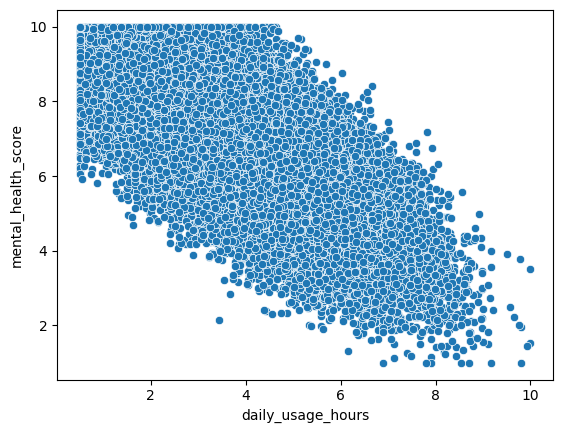

In [ ]:
sns.scatterplot(x='daily_usage_hours', y='mental_health_score', data=df)

<Axes: xlabel='addiction_level', ylabel='night_usage'>

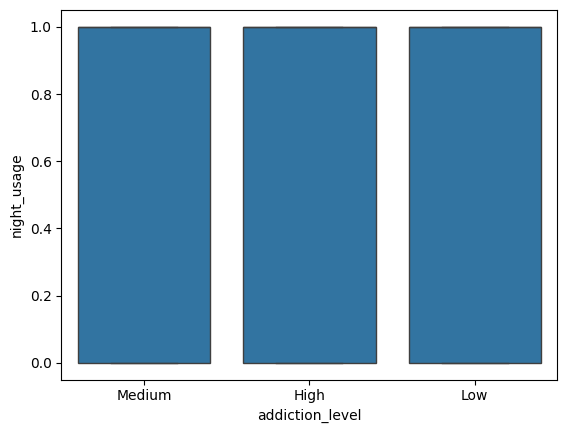

In [ ]:
sns.boxplot(x='addiction_level', y='night_usage', data=df)

<Axes: xlabel='primary_platform', ylabel='count'>

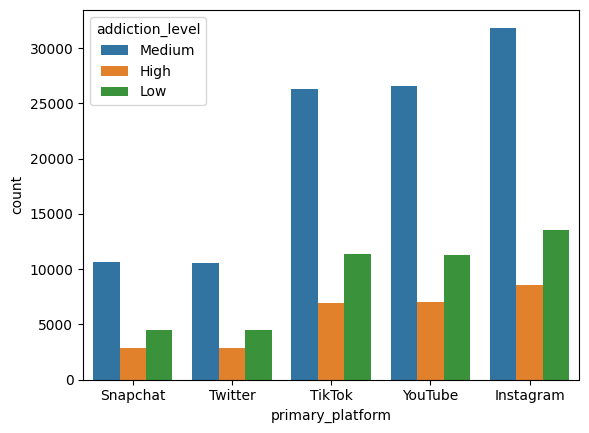

In [ ]:
sns.countplot(x='primary_platform', hue='addiction_level', data=df)

In [ ]:
df.groupby('country')['daily_usage_hours'].mean().sort_values()

,daily_usage_hours
country,
USA,3.498578
Canada,3.503107
India,3.513759
Germany,3.520491
Brazil,3.520717
UK,3.526152
Australia,3.534239


# Platform × Purpose heatmap

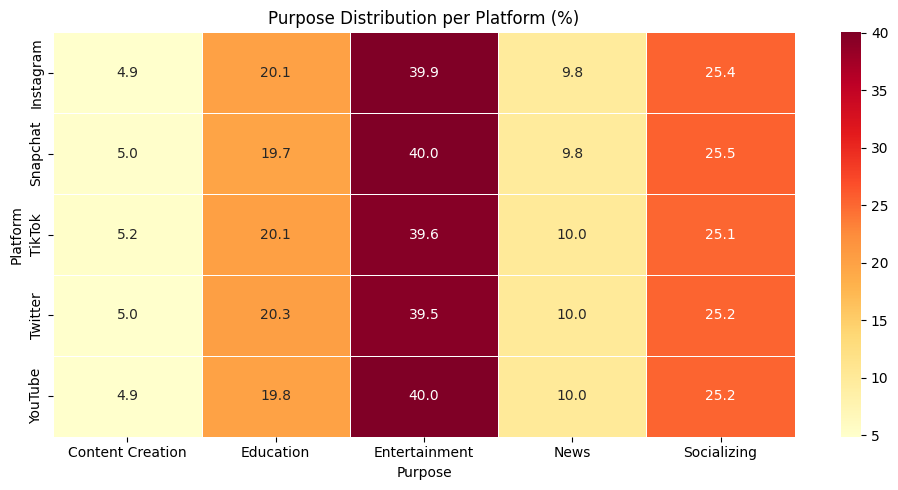

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivot = df.groupby(['primary_platform', 'purpose']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Purpose Distribution per Platform (%)')
plt.ylabel('Platform')
plt.xlabel('Purpose')
plt.tight_layout()
plt.show()

Berdasarkan gambar diatas bisa kita simpulkan bahwa

1.   **Entertainment** menjadi tujuan utama di semua platform (~39-40%)
2.   **Socializing** berada di urutan kedua (~25%), menandakan interaksi sosial tetap menjadi fungsi penting.
3. **News** memiliki porsi lebih kecil (~19-20%), menunjukkan peran platform sebagai sumber pembelajaran cukup signifikan.
4. **Content Creation** paling rendah (~4.9-5.2%), menunjukkan hanya sebagian kecil pengguna yang aktif membuat konten.

Distribusi penggunaan relatif konsisten di semua platform (Instagram, Snapchat, Tiktok, Twitter, YouTube). Tidak ada platform yang menunjukkan perbedaan signifikan dalam pola tujuan penggunaan.

**Kesimpulan**<br>
Pola penggunaan media sosial cenderung seragam, dengan fokus utama pada hiburan dan interaksi sosial.Fungsi lain seperti edukasi, berita, dan pembuatan konten bersifat pelengkap.


#  Distribusi waktu harian per platform

/tmp/ipykernel_8634/3150624206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


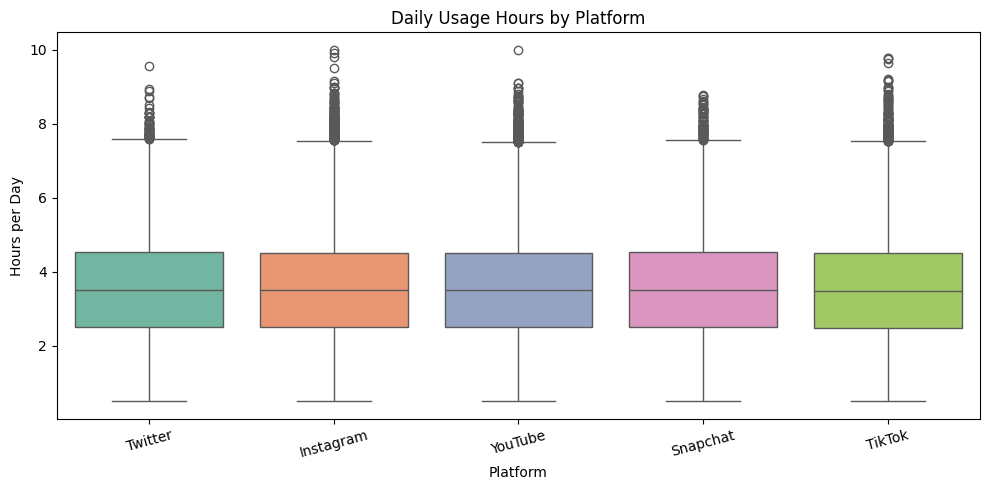

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='primary_platform',
    y='daily_usage_hours',
    order=df.groupby('primary_platform')['daily_usage_hours'].median()
            .sort_values(ascending=False).index,
    palette='Set2'
)
plt.title('Daily Usage Hours by Platform')
plt.xlabel('Platform')
plt.ylabel('Hours per Day')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Dari gambar tersebut bisa dilihat bahwa :


1.   Median waktu penggunaan di semua platform relatif mirip, sekitar 3-5 jam per hari.
2.   Sebaran (variability) penggunaan cukup lebar, dengan sebagian pengguna hanya ~1 jam, sementara lainnya bisa mencapai 7-8 jam.
3. Terdapat banyak oulier di semua platform, bahkan hingga 9-10 jam per hari menunjukkan adanya heavy users.

Perbandingan Antar Platfom


*   Tidak ada perbedaan signifikan antar platfom (Twitter, Instagram, Youtube, Snpapchat, Tiktok)
*   Semua platform memiliki distribusi yang hampir identik dan median dan IQR yang serupa.
*   Sedikit variasi yang diperoleh bahwa Tiktok dan Instagram tampak memiliki lebih banyak pengguna dengan durasi tinggi (outliers) dan Twitter cenderung sedikit lebih stabil (variasi sedikit lebih kecil)

**Kesimpulan**

*   Pola penggunaan harian media sosial konsisten di semua platform .
*   Perbedaan utama bukan pada platform, tetapi pada perilaku pengguna (light vs heavy users)









# Pola penggunaan malam berdasarkan gender & platform

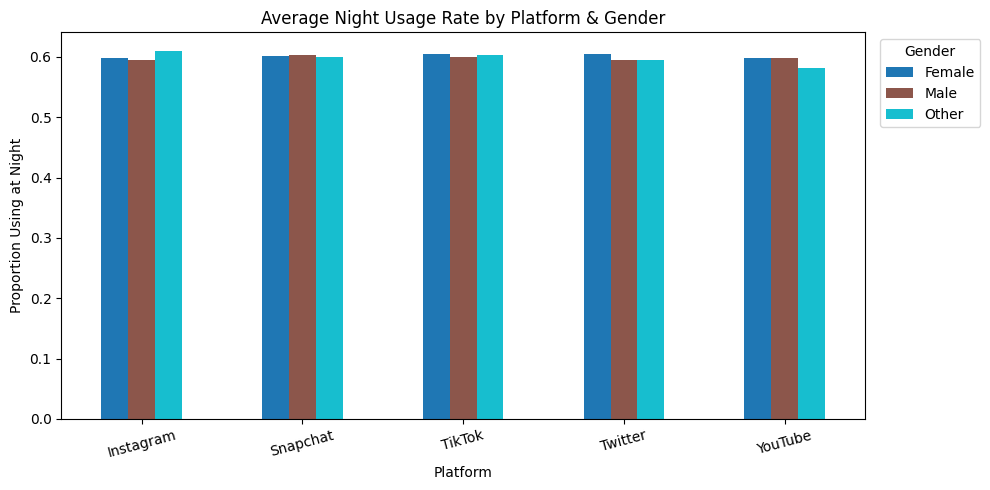

In [ ]:
night_pivot = df.groupby(['primary_platform', 'gender'])['night_usage'].mean().unstack()

night_pivot.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='none')
plt.title('Average Night Usage Rate by Platform & Gender')
plt.ylabel('Proportion Using at Night')
plt.xlabel('Platform')
plt.xticks(rotation=15)
plt.legend(title='Gender', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight Average Night Usage Rate by Platform & Gender


*   Proporsi penggunaan pada malam hari di semua platform berada di kisaran (~59%-61%). Hal ini menunjukkan bahwa mayoritas pengguna aktif menggunakan media sosial pada malam hari.
*   Perbedaan antar gender sangat kecil di semua platform. Pola penggunaan malam hari cenderung konsisten antara **Female**, **Male**, dan **Other**.
*   Sedikit variasi : Gender **other** sedikit lebih tinggi di Instagram, Gender **Male** sedikit lebih tinggi di Snapchat, Gender **Female** relatif stabil di semua platform.
*   Tidak ada platform yang dominan secara signifikan
*   Semua platform (Instagram, Snapchat, Tiktok, Twitter, Youtube) menunjukkan tingkat penggunaan malam yang hampir sama.

**Kesimpulan**

*   Penggunaan media sosial pada malam hari adalah perilaku umum di semua platform dan gender
*   Faktor gender maupun platform tidak memberikan perbedaan signifikan terhadap pola ini.







# Multi-correlation matrix (variabel numerik ke mental health)

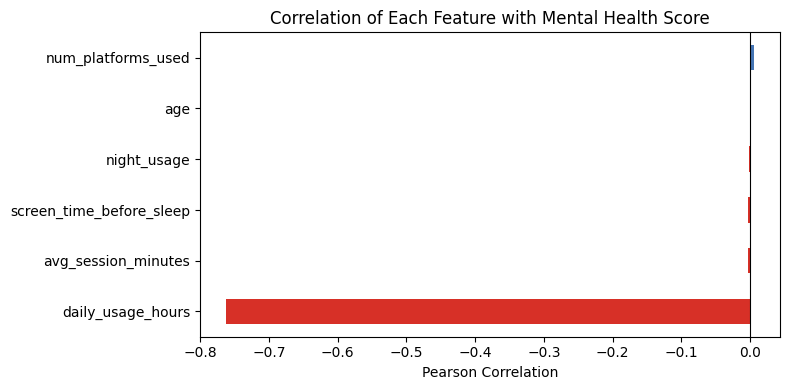

daily_usage_hours          -0.762107
avg_session_minutes        -0.003572
screen_time_before_sleep   -0.002742
night_usage                -0.001016
age                        -0.000464
num_platforms_used          0.005062


In [ ]:
num_cols = ['age', 'daily_usage_hours', 'num_platforms_used',
            'avg_session_minutes', 'night_usage',
            'screen_time_before_sleep', 'mental_health_score']

corr_matrix = df[num_cols].corr()
mental_corr = corr_matrix['mental_health_score'].drop('mental_health_score').sort_values()

plt.figure(figsize=(8, 4))
colors = ['#d73027' if v < 0 else '#4575b4' for v in mental_corr]
mental_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Each Feature with Mental Health Score')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(mental_corr.to_string())

Analisis Korelasi Fitur terhadap Mental Health Score <br>
Berdasarkan grafik korelasi Pearson,fitur daily_usage_hours memiliki korelasi negatif paling kuat terhadap mental health score dengan nilai skala sekitar -0.762. Hal ini menunjukkan bahwa semakin tinggi durasi penggunaan harian media sosial, maka skor kesehatan mental cenderung menurun secara signifikan.

Sementara itu, fitur lain seperti avg_session_minutes, screen_time_before_sleep, night_usage, dan age memiliki nilai korelasi yang sangat kecil (mendekati 0), sehingga pengaruh linear terhadap mental health score tergolong lemah atau hampir tidak ada.

Fitur num_platforms_used menunjukkan korelasi positif yang sangat kecil (0.005), yang berarti jumlah platform yang digunakan tidak memiliki hubungan signifikan dengan skor kesehatan mental.

**Kesimpulan**
Secara keseluruhan, durasi penggunaan harian (daily_usage_hours) merupakan faktor yang paling berpengaruh terhadap kesehatan mental dibandingkan fitur lainnya, sedangkan fitur-fitur lain menunjukkan hubungan yang relatif tidak signifikan berdasarkan analisis korelasi Pearson.

# Mental health score per addiction level (violin plot)

/tmp/ipykernel_8634/4262205928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


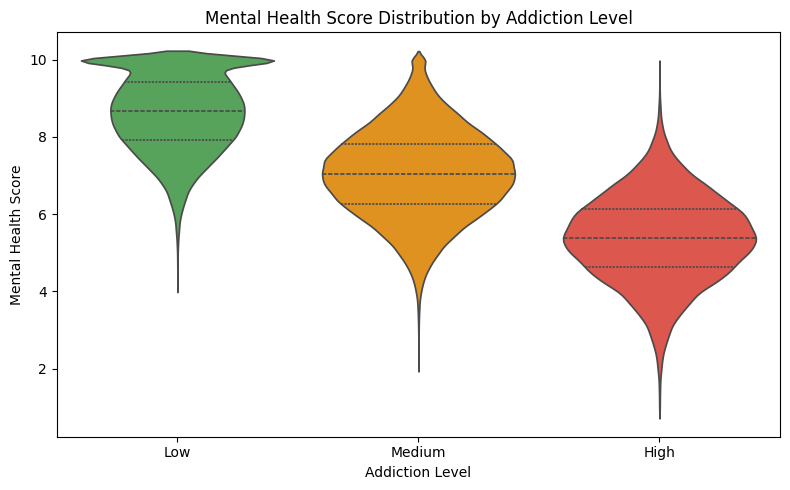

In [ ]:
plt.figure(figsize=(8, 5))
order = ['Low', 'Medium', 'High']
sns.violinplot(
    data=df,
    x='addiction_level',
    y='mental_health_score',
    order=order,
    palette={'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'},
    inner='quartile'
)
plt.title('Mental Health Score Distribution by Addiction Level')
plt.xlabel('Addiction Level')
plt.ylabel('Mental Health Score')
plt.tight_layout()
plt.show()

Grafik menunjukkan distribusi Mental Health Score berdasarkan tingkat Addiction Level (Low, Medium, High)

*   **Low Addiction** memiliki skor kesehatan mental paling tinggi, dengan mayoritas nilai berada di rentang 8-10. Ini menunjukkan kondisi mental cenderung lebih baik pada tingkat kecanduan rendah.
*   **Medium Addiction** menunjukkan penurunan skor kesehatan mental, dengan distribusi terbesar berada di sekitar 6-8
*   High Addiction memiliki skor kesehatan mental paling rendah, mayoritas berada pada rentang 4-6, yang mengindikasikan kondisi mental yang lebih buruk.

Secara keseluruhan, grafik memperlihatkan adanya hubungan negatif antara tingkat kecanduan dan kesehatan mental: semakin tinggi tingkat kecanduan, semakin rendah skor kesehatan mental.





#Scatter daily usage vs mental health, diwarnai addiction level

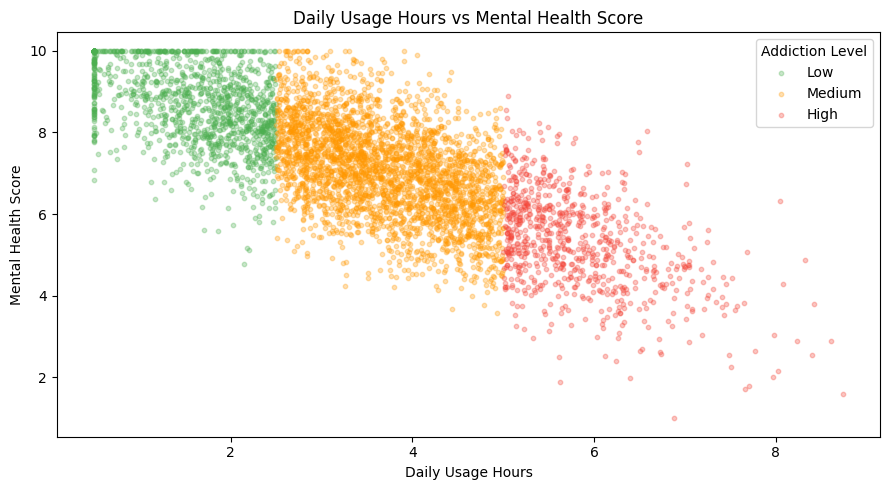

In [ ]:
sample = df.sample(5000, random_state=42)
palette = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

plt.figure(figsize=(9, 5))
for level in ['Low', 'Medium', 'High']:
    subset = sample[sample['addiction_level'] == level]
    plt.scatter(
        subset['daily_usage_hours'],
        subset['mental_health_score'],
        label=level, alpha=0.3, s=10, color=palette[level]
    )

plt.title('Daily Usage Hours vs Mental Health Score')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Mental Health Score')
plt.legend(title='Addiction Level')
plt.tight_layout()
plt.show()

Grafik menunjukkan hubungan antara Daily Usage Hours dan Mental Health Score berdasarkan tingkat Addiction Level

*   Terdapat tren negatif antara durasi penggunaan harian dan skor kesehatan mental. Semakin lama waktu penggunaan, skor kesehatan mental cenderung menurun.
*   Pengguna dengan Low Addiction umumnya memiliki waktu penggunaan lebih rendah(sekitar 0.5-2.5 jam) dan skor kesehatan mental lebih tinggi (7-10)
*   Kelompok Medium Addiction berada pada penggunaan menengah(sekitar 2.5-5jam) dengan skor kesehatan mental yang mulai menurun (5-8)
*   Pengguna dengan High Addiction memiliki durasi penggunaan paling tinggi (lebih dari 5 jam) dan skor kesehatan mental paling rendah, sebagian besar berada pada rentang 3-6.





#  Persiapan fitur untuk clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

cluster_features = [
    'daily_usage_hours', 'avg_session_minutes',
    'num_platforms_used', 'night_usage',
    'mental_health_score', 'screen_time_before_sleep'
]

df_cluster = df[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster)
print("Shape untuk clustering:", X_cluster.shape)

Shape untuk clustering: (179344, 6)


# Elbow method untuk menentukan K optimal

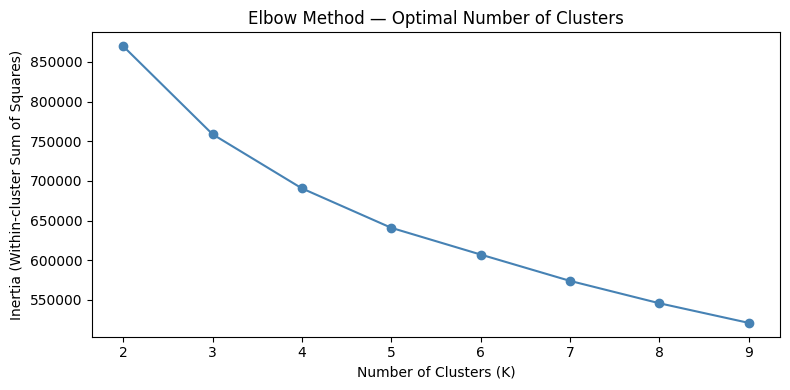

In [ ]:
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

# Fit KMeans & beri label cluster

In [ ]:
OPTIMAL_K = 4  # sesuaikan dengan hasil elbow

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

print("Distribusi cluster:")
print(df['cluster'].value_counts().sort_index())

Distribusi cluster:
cluster
0    34952
1    52432
2    36890
3    55070
Name: count, dtype: int64


# Visualisasi cluster dengan PCA 2D

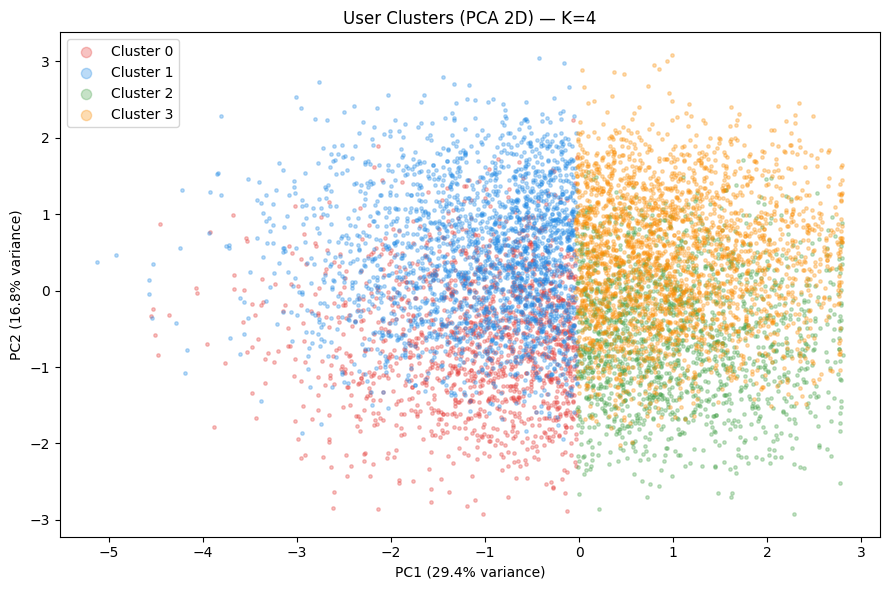

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].values

sample_pca = df_pca.sample(8000, random_state=42)

plt.figure(figsize=(9, 6))
palette_cluster = {0: '#E53935', 1: '#1E88E5', 2: '#43A047', 3: '#FB8C00'}
for c in range(OPTIMAL_K):
    sub = sample_pca[sample_pca['cluster'] == c]
    plt.scatter(sub['PC1'], sub['PC2'], s=6, alpha=0.3,
                label=f'Cluster {c}', color=palette_cluster[c])

plt.title(f'User Clusters (PCA 2D) — K={OPTIMAL_K}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

#  Profil tiap cluster (cluster persona)

=== Cluster Profiles (Mean Values) ===
         daily_usage_hours  avg_session_minutes  num_platforms_used  night_usage  mental_health_score  screen_time_before_sleep
cluster                                                                                                                        
0                     4.65                25.22                2.98          0.0                 6.00                     40.14
1                     4.65                25.18                2.97          1.0                 6.00                     40.34
2                     2.43                25.07                2.99          0.0                 8.28                     39.96
3                     2.43                25.00                3.02          1.0                 8.29                     39.97


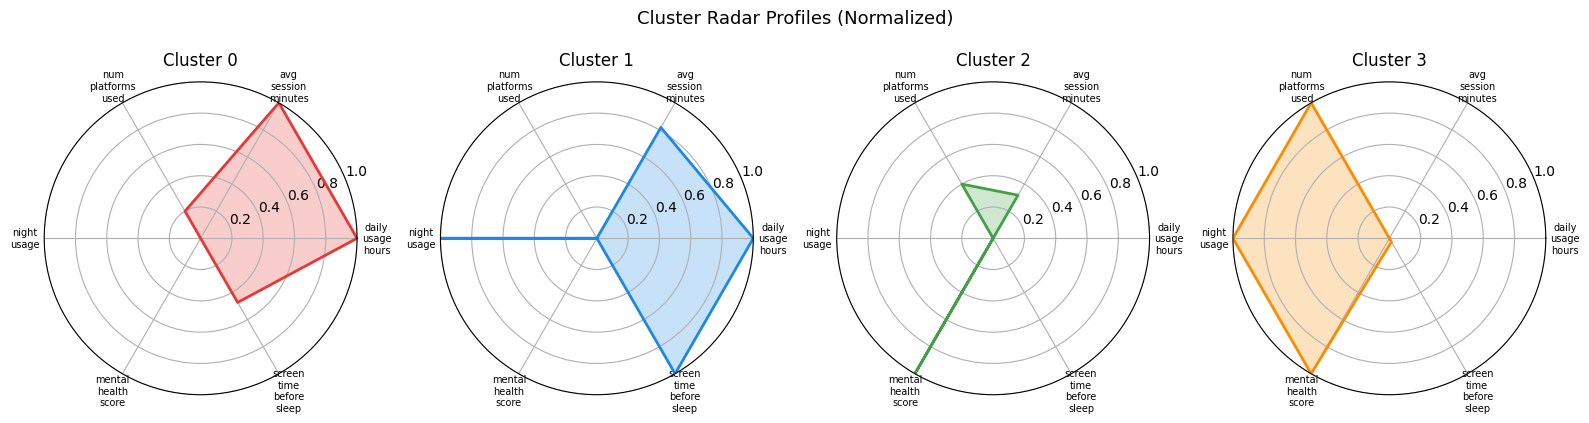

In [ ]:
cluster_profile = df.groupby('cluster')[cluster_features].mean().round(2)
print("=== Cluster Profiles (Mean Values) ===")
print(cluster_profile.to_string())

# Radar chart per cluster
from matplotlib.patches import FancyArrowPatch
import numpy as np

labels = cluster_features
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(4 * OPTIMAL_K, 4),
                          subplot_kw=dict(polar=True))

cluster_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

for i, ax in enumerate(axes):
    values = cluster_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=list(palette_cluster.values())[i], linewidth=2)
    ax.fill(angles, values, color=list(palette_cluster.values())[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([l.replace('_', '\n') for l in labels], size=7)
    ax.set_title(f'Cluster {i}', size=12, pad=12)
    ax.set_ylim(0, 1)

plt.suptitle('Cluster Radar Profiles (Normalized)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Ringkasan metrik utama per negara

In [ ]:
country_stats = df.groupby('country').agg(
    avg_daily_hours=('daily_usage_hours', 'mean'),
    avg_mental_health=('mental_health_score', 'mean'),
    avg_session_min=('avg_session_minutes', 'mean'),
    night_usage_rate=('night_usage', 'mean'),
    n_users=('age', 'count')
).round(3).sort_values('avg_daily_hours', ascending=False)

print(country_stats.to_string())

           avg_daily_hours  avg_mental_health  avg_session_min  night_usage_rate  n_users
country                                                                                  
Australia            3.534              7.152           25.000             0.594     8848
UK                   3.526              7.163           25.128             0.599    18190
Brazil               3.521              7.176           25.140             0.602    17850
Germany              3.520              7.163           25.207             0.601    17845
India                3.514              7.164           25.146             0.599    63078
Canada               3.503              7.184           24.907             0.595    17906
USA                  3.499              7.187           25.111             0.602    35627


# Grouped bar chart: daily usage & mental health per negara

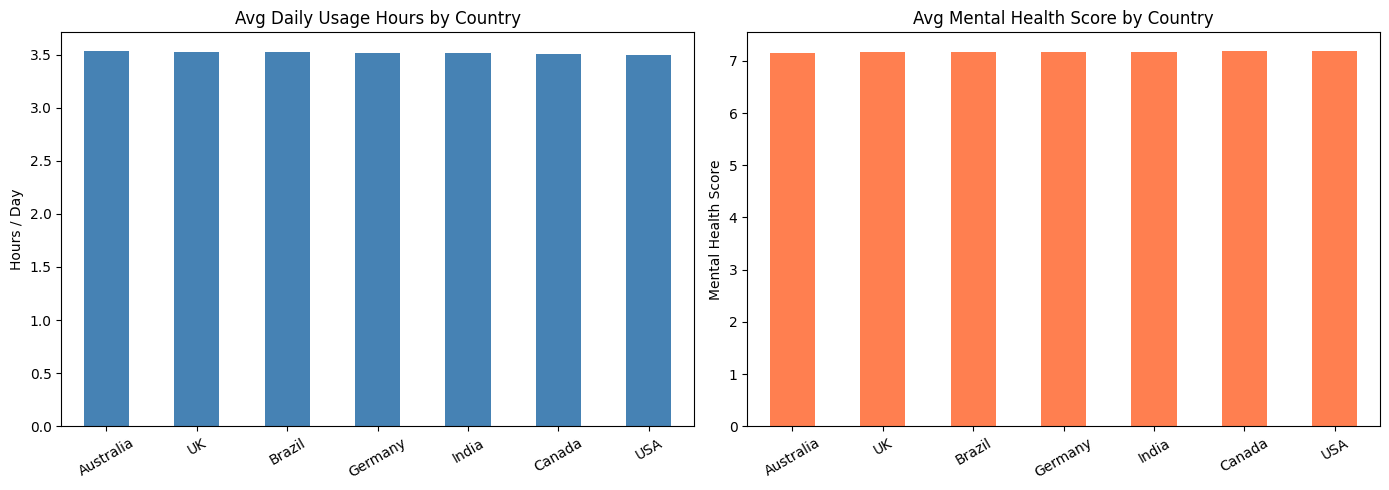

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_stats['avg_daily_hours'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='none'
)
axes[0].set_title('Avg Daily Usage Hours by Country')
axes[0].set_ylabel('Hours / Day')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

country_stats['avg_mental_health'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='none'
)
axes[1].set_title('Avg Mental Health Score by Country')
axes[1].set_ylabel('Mental Health Score')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Addiction level distribution per negara (stacked bar)

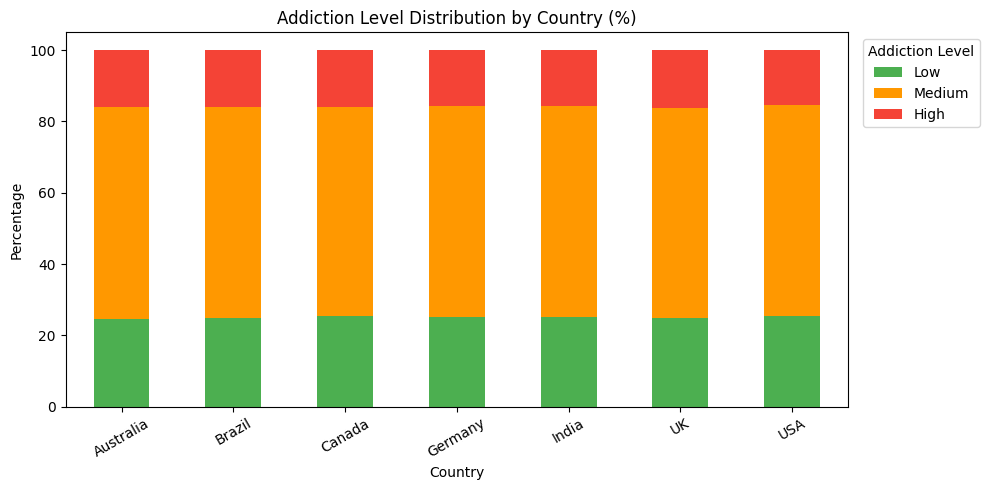

In [ ]:
addiction_country = (
    df.groupby(['country', 'addiction_level'])
    .size()
    .unstack(fill_value=0)
)
addiction_pct = addiction_country.div(addiction_country.sum(axis=1), axis=0) * 100

addiction_pct[['Low', 'Medium', 'High']].plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color={'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'},
    edgecolor='none'
)
plt.title('Addiction Level Distribution by Country (%)')
plt.ylabel('Percentage')
plt.xlabel('Country')
plt.legend(title='Addiction Level', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ANOVA test: apakah daily usage berbeda signifikan antar negara?

In [ ]:
from scipy import stats

groups = [group['daily_usage_hours'].values for _, group in df.groupby('country')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"One-Way ANOVA: daily_usage_hours across countries")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✓ Terdapat perbedaan signifikan daily usage antar negara (p < 0.05)")
else:
    print("✗ Tidak ada perbedaan signifikan (p ≥ 0.05)")

One-Way ANOVA: daily_usage_hours across countries
  F-statistic : 1.4207
  p-value     : 0.202158

✗ Tidak ada perbedaan signifikan (p ≥ 0.05)


# Heatmap perbandingan semua metrik antar negara

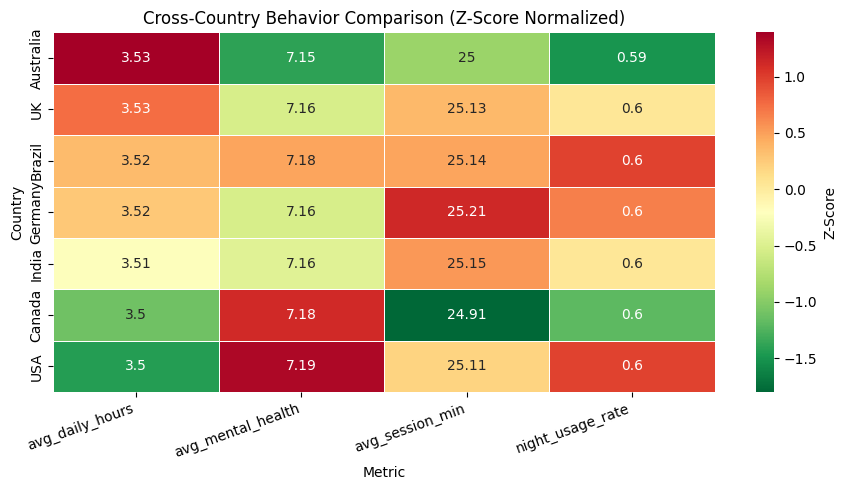

In [ ]:
metrics = ['avg_daily_hours', 'avg_mental_health', 'avg_session_min', 'night_usage_rate']
heatmap_data = country_stats[metrics].copy()

# Normalize per kolom agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.round(2),   # nilai asli sebagai anotasi
    fmt='g',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Z-Score'}
)
plt.title('Cross-Country Behavior Comparison (Z-Score Normalized)')
plt.xlabel('Metric')
plt.ylabel('Country')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()